In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore', category=RuntimeWarning)
print('Imports OK')

Imports OK


In [2]:
# ── Cell 2: Paths + subjects ──────────────────────────────────────────────────
_BASE = (
    '/Users/farjam/Library/CloudStorage'
    '/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP'
)
MDS_ROOT   = Path(_BASE) / 'MDS'
NR_ROOT    = Path(_BASE) / 'NR'
PLOTS_ROOT = Path(_BASE) / 'Plots'

AGE_DATA = {
    '1001': 25.0, '1002': 43.0, '1004': 33.0, '1005': 50.0, '1007': 31.0,
    '1008': 25.0, '1010': 26.0, '1011': 37.0, '1014': 23.0, '1016': 36.0,
    '1017': 46.0, '1018': 25.0, '1020': 29.0, '1021': 28.0, '1023': 46.0,
    '1024': 24.0, '1026': 25.0, '1028': 62.0, '1034': 60.0, '1038': 45.0,
    '1039': 63.0, '1041': 49.0, '1042': 39.0, '1044': 62.0, '1046': 61.0,
    '1052': 53.0, '2002': 62.0, '2006': 25.0, '2009': 49.0, '2017': 31.0,
    '2020': 43.0, '2023': 49.0, '2026': 47.0, '2028': 29.0, '2029': 50.0,
    '2037': 45.0, '3001': 54.0, '3005': 39.0, '3006': 33.0, '3007': 41.0,
    '3008': 32.0, '3011': 31.0, '3014': 34.0, '3016': 44.0, '3027': 72.0,
    '3030': 54.0, '3034': 48.0, '3039': 34.0, '3041': 35.0,
}
SUBJECTS = list(AGE_DATA.keys())

PATHWAYS = {
    'Luminance': {
        'contrasts': np.array([0.035, 0.07,  0.14,  0.28],  float),
        'color':     '#555555',
    },
    'L-M': {
        'contrasts': np.array([0.008, 0.016, 0.032, 0.064], float),
        'color':     '#b23333',
    },
    'S-cone': {
        'contrasts': np.array([0.06,  0.12,  0.24,  0.48],  float),
        'color':     '#3333cc',
    },
}

TIME_RANGE = [0.05, 0.30]   # seconds — analysis window
FIX_N      = 2.0            # Hill exponent fixed for stability across subjects

print(f'Subjects : {len(SUBJECTS)}')
print(f'NR root  : {NR_ROOT}')

Subjects : 49
NR root  : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/NR


In [11]:
# ── Cell 3: Pathway choice ────────────────────────────────────────────────────
# Change PATHWAY here, then re-run this cell before running Cells 5 and 6.

PATHWAY = 'S-cone'   # ← 'Luminance', 'L-M', or 'S-cone'

mds_dir   = MDS_ROOT   / PATHWAY
nr_dir    = NR_ROOT    / PATHWAY
plots_dir = PLOTS_ROOT / PATHWAY
nr_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

contrasts = PATHWAYS[PATHWAY]['contrasts']
color     = PATHWAYS[PATHWAY]['color']

print(f'Pathway  : {PATHWAY}')
print(f'MDS dir  : {mds_dir}')
print(f'NR dir   : {nr_dir}')

Pathway  : S-cone
MDS dir  : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/MDS/S-cone
NR dir   : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/NR/S-cone


In [12]:
# ── Cell 4: Helper functions ──────────────────────────────────────────────────

def naka_rushton(c, Rmax, C50):
    """
    Naka-Rushton with fixed Hill exponent n = FIX_N.
    R(c) = Rmax * c^n / (c^n + C50^n)
    """
    c = np.asarray(c, float)
    return Rmax * (c ** FIX_N) / (c ** FIX_N + C50 ** FIX_N)


def fit_nr(contrasts, y):
    """
    Fit Naka-Rushton to (contrasts, y).
    Returns (Rmax, C50) or (nan, nan) if fit fails.
    """
    c = np.asarray(contrasts, float)
    y = np.asarray(y, float)
    try:
        p0     = [1.0, np.median(c) / 2.0]
        bounds = ([0.0, c.min() / 10.0], [np.inf, c.max()])
        popt, _ = curve_fit(naka_rushton, c, y,
                            p0=p0, bounds=bounds, maxfev=20000)
        return float(popt[0]), float(popt[1])
    except Exception:
        return np.nan, np.nan


def peak_idx(t, values):
    """Index of peak within TIME_RANGE, fallback to global peak."""
    inr = (t >= TIME_RANGE[0]) & (t <= TIME_RANGE[1])
    if np.any(inr):
        return int(np.where(inr)[0][np.argmax(values[inr])])
    return int(np.argmax(values))


print('Helpers OK')

Helpers OK


In [13]:
# ── Cell 5: Fit + save NR results ─────────────────────────────────────────────
# Skips subjects whose file already exists — safe to re-run.
#
# Saves per subject:
#   sub-<ID>_nr_results.npz  (in NR/<pathway>/)
#
#   time       (n_win,)    window centre times in seconds
#   Rmax       (n_win,)    max response — NaN where QC failed or fit failed
#   C50        (n_win,)    semi-saturation contrast — same NaN rule
#   peak_time  scalar      time of best NR fit within TIME_RANGE (seconds)
#   peak_Rmax  scalar      Rmax at peak_time
#   peak_C50   scalar      C50 at peak_time
#   age        scalar      participant age in years

for subject in SUBJECTS:
    out = nr_dir / f'sub-{subject}_nr_results.npz'
    if out.exists():
        print(f'[{subject}] already done — skip')
        continue

    f_mds = mds_dir / f'sub-{subject}_mds_timecourses.npz'
    if not f_mds.exists():
        print(f'[{subject}] no MDS file — skip')
        continue

    try:
        with np.load(f_mds, allow_pickle=False) as d:
            time    = d['time'].astype(float)       # (n_win,)
            X       = d['X'].astype(float)          # (n_win, 4) MDS projections
            qc_mask = d['qc_mask'].astype(bool)     # (n_win,)

        nW = len(time)
        Rmax_t = np.full(nW, np.nan)
        C50_t  = np.full(nW, np.nan)

        # Fit NR only at windows that passed MDS QC
        for i in range(nW):
            if not qc_mask[i]:
                continue
            Rmax_t[i], C50_t[i] = fit_nr(contrasts, X[i])

        # Find peak window: best Rmax within TIME_RANGE (ignoring NaN)
        Rmax_clean = np.where(np.isfinite(Rmax_t), Rmax_t, 0.0)
        pidx = peak_idx(time, Rmax_clean)

        np.savez(out,
                 time      = time,
                 Rmax      = Rmax_t,
                 C50       = C50_t,
                 peak_time = np.float64(time[pidx]),
                 peak_Rmax = np.float64(Rmax_t[pidx]),
                 peak_C50  = np.float64(C50_t[pidx]),
                 age       = np.float64(AGE_DATA[subject]))

        print(f'[{subject}] saved | '
              f'peak @ {time[pidx]:.3f}s | '
              f'Rmax={Rmax_t[pidx]:.3f} | '
              f'C50={C50_t[pidx]:.4f}')

    except Exception as e:
        print(f'[{subject}] error: {e}')

[1001] saved | peak @ 0.129s | Rmax=1.759 | C50=0.4153
[1002] saved | peak @ 0.273s | Rmax=1.954 | C50=0.4800
[1004] saved | peak @ 0.059s | Rmax=1.983 | C50=0.4800
[1005] saved | peak @ 0.262s | Rmax=2.013 | C50=0.4800
[1007] saved | peak @ 0.188s | Rmax=1.966 | C50=0.4692
[1008] saved | peak @ 0.270s | Rmax=1.996 | C50=0.4800
[1010] saved | peak @ 0.195s | Rmax=1.342 | C50=0.2777
[1011] saved | peak @ 0.254s | Rmax=1.426 | C50=0.2963
[1014] saved | peak @ 0.117s | Rmax=1.990 | C50=0.4800
[1016] saved | peak @ 0.074s | Rmax=1.915 | C50=0.4696
[1017] saved | peak @ 0.148s | Rmax=1.866 | C50=0.4800
[1018] saved | peak @ 0.121s | Rmax=1.971 | C50=0.4800
[1020] saved | peak @ 0.238s | Rmax=2.004 | C50=0.4800
[1021] saved | peak @ 0.188s | Rmax=1.974 | C50=0.4745
[1023] saved | peak @ 0.117s | Rmax=1.894 | C50=0.4800
[1024] saved | peak @ 0.117s | Rmax=2.005 | C50=0.4800
[1026] saved | peak @ 0.109s | Rmax=1.697 | C50=0.3949
[1028] saved | peak @ 0.191s | Rmax=1.980 | C50=0.4800
[1034] sav

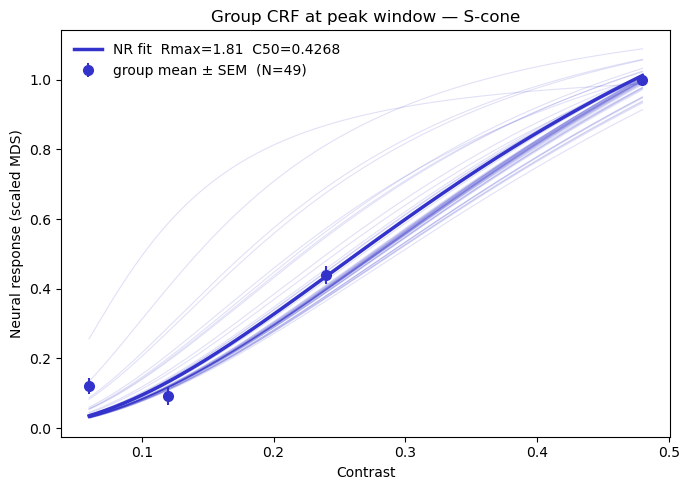

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/S-cone/S-cone_group_CRF.png


In [14]:
# ── Cell 6: Group CRF plot at peak window ────────────────────────────────────
#
# For each subject, takes their MDS values at peak_time and overlays
# the NR fit. Then plots the group average CRF with ± SEM shading.
# Uses PATHWAY set in Cell 3.

c_line = np.linspace(contrasts.min(), contrasts.max(), 300)

all_y     = []   # MDS values at each subject's peak
all_Rmax  = []
all_C50   = []

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title(f'Group CRF at peak window — {PATHWAY}')

for subject in SUBJECTS:
    f_nr  = nr_dir  / f'sub-{subject}_nr_results.npz'
    f_mds = mds_dir / f'sub-{subject}_mds_timecourses.npz'
    if not f_nr.exists() or not f_mds.exists():
        continue

    with np.load(f_nr,  allow_pickle=False) as d:
        peak_time = float(d['peak_time'])
        Rmax      = float(d['peak_Rmax'])
        C50       = float(d['peak_C50'])

    with np.load(f_mds, allow_pickle=False) as d:
        time = d['time'].astype(float)
        X    = d['X'].astype(float)

    # Find the window closest to this subject's peak_time
    widx = int(np.argmin(np.abs(time - peak_time)))
    y    = X[widx]

    if not np.isfinite(Rmax) or not np.isfinite(C50):
        continue

    all_y.append(y)
    all_Rmax.append(Rmax)
    all_C50.append(C50)

    # Individual subject fit (thin, transparent)
    ax.plot(c_line, naka_rushton(c_line, Rmax, C50),
            color=color, lw=0.8, alpha=0.15)

if all_y:
    # Group average MDS data points
    Y    = np.vstack(all_y)
    y_m  = np.nanmean(Y, 0)
    y_s  = np.nanstd(Y, 0, ddof=1) / np.sqrt(Y.shape[0])

    # Group average NR fit using mean parameters
    Rmax_m = float(np.nanmean(all_Rmax))
    C50_m  = float(np.nanmean(all_C50))

    ax.errorbar(contrasts, y_m, yerr=y_s,
                fmt='o', color=color, ms=7, zorder=5,
                label=f'group mean ± SEM  (N={Y.shape[0]})')
    ax.plot(c_line, naka_rushton(c_line, Rmax_m, C50_m),
            color=color, lw=2.5,
            label=f'NR fit  Rmax={Rmax_m:.2f}  C50={C50_m:.4f}')

ax.set_xlabel('Contrast')
ax.set_ylabel('Neural response (scaled MDS)')
ax.legend(frameon=False)
fig.tight_layout()

out = plots_dir / f'{PATHWAY}_group_CRF.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')